# Capstone Project: Patient Classification and Readmission Prediction

**Question**: Can real-world evidence (RWE) from patient records be used to stratify patients with a specific disease into risk groups and predict their likelihood of readmission? 



### The Data

Our dataset comes from Kaggle [link](https://www.kaggle.com/datasets/sulphatet/diabetes-130us-hospitals-for-years-19992008). The dataset focuses on patients with diabetes as a primary diagnosis. It represents 10 years (1999-2008) of clinical care across 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. 

Two additional files are to be used in this exercies. The first is to assign the categorical labels for the numeralized features: admission type, discharge disposition, and admission sources. The second data file is a list of diagnoses pertaining to the ICD-9-CM codes used in the three diagnoses features (diag_1, diag_2, diag_3). ICD-9-CM are the standardized set of codes health care physicians (HCPs) utilize for patient charts, coding, and electronic medical records (EMRs). 


### Understanding the Data

To begin, we will run a series of code to analyze the status of our dataset. We will identify data types, missing data, and assess overall data structure that may present limitations its later application for modeling. 


In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset 
dbts= pd.read_csv("data/diabetic_data.csv")

# Missing values (percentage)
missing_counts=dbts.isnull().sum()
missing_percent=(dbts.isnull().sum() / len(dbts)) * 100
missing_summary=pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})


# Display dataset summary
print(dbts.dtypes)
print(dbts.describe())
print(missing_summary)


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

Some oddities arise in our data regarding the typing. For example, 'weight','age' and 'A1C' are supposed to be numerical and theoretically bear great influence on our future model. Conversely, the diagnostic data we expect to be categorical are indeed integers. This stems from the use of ICD-9-CM coding that will have to be mapped against the diagnosis description to aid analysis. 

Unfortunately, 'A1C' and 'max_glu_serum' have over 80% of missing values. They will have to be excluded from our analysis. Another question arises when observing 'encounter_id' and 'patient_nbr'. It is possible that the same patient was hospitalized within our 10 year period. If so, we will have to identify these patients and decide on which encounter to utilize: first, last, or some combination. 

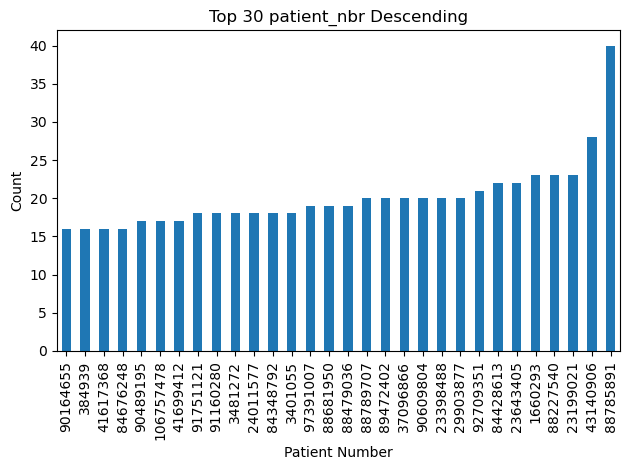

In [2]:
# Identifying patients with multiple encounters
counts = dbts['patient_nbr'].value_counts().head(30)

counts.sort_values().plot(kind='bar')

plt.title('Top 30 patient_nbr Descending')
plt.xlabel('Patient Number')
plt.ylabel('Count')
plt.tight_layout()

plt.show()

In [3]:
# Dozens of patients have multiple encounters
# While clinically significant, for the purposes of this exercise (the goal of which is to prove predictive power),
# this presents a data leakage risk. For the purposes of predicting readmission, I will only use the first encounter. 
# For the purpose of clustering, I will use an aggregate of the encounters. 

In [4]:
# Understanding Diagnoses
dbts[['diag_1','diag_2','diag_3']].head()

# these will need to be mapped against a reference sheet to make sense of the ICD-9-CM codes into actual diagnoses

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250


### Cleaning the Data

The following steps will be taken to prepare the data for analysis and modeling: missing observations will be removed, features with a majority of missing values will be excluded, 'object' features that require corresponding labels will be relabeled and binned into smaller broader categories to diminish the number of features (i.e. diagnoses will be categorized into "Broad Category" reducing the variables from 241 to 16).

For the purpopse of clustering and predicting classification into readmission, we will be utilizing only the first encounter presented per patient. The logic being that the model should be able to predict readmission based on the first visit. We can randomly select a sample from the remaining data (ensuring to only pull one encounter per patient) and use it to test our model. 

In [5]:
# We begin by removing features where a majority of their data is missing.
# A1Cresult, Max Glucose Serum, Weight, Payer (has no bearing on clinical outcome), Medical Specialty (cannot predict specialty for
# a new patient) 
dbts=dbts.drop(columns=['max_glu_serum','A1Cresult','weight','medical_specialty','payer_code'])

In [6]:
# Importing ICD-9-CM diagnoses reference sheet
icd9= pd.read_csv("data/icd9.csv")

# Mapping ICD-9-CM codes to diagnoses
# Issue presented where codes don't match up perfectly while data is 'object' type or 'int64' type. 'str' type will be necessary.
diag_columns=['diag_1','diag_2','diag_3']

# Converting codes to 'str'. Removing spaces and standardizing format. 
# Additionally, because we only need the "Broad Category" for diagnoses, we can drop the '.' and more 
# accurate diagnoses to simplify. This will require removing duplicates as indexing requires unique values.

for col in diag_columns:
    dbts[col]=dbts[col].astype(str).str.strip().str.split('.').str[0].str.upper()

icd9['ICD9_Code']=icd9['ICD9_Code'].astype(str).str.strip().str.split('.').str[0].str.upper()


icd9=(icd9.groupby('ICD9_Code')['Broad_Category'].first().reset_index())


# Creat mapping dictionary for diagnoses
icd9_map=dict(zip(icd9['ICD9_Code'], icd9['Broad_Category']))

# Map diagnoses

for col in diag_columns:
    dbts[col+'_cat']=dbts[col].map(icd9_map)


# Check for diagnoses mapping
dbts[['diag_1_cat','diag_2_cat','diag_3_cat']].head(100)
#print(dbts.dtypes)


,diag_1_cat,diag_2_cat,diag_3_cat
0,Diabetes Mellitus,NaN,NaN
1,Endocrine & Metabolic,Diabetes Mellitus,Endocrine & Metabolic
2,"Pregnancy, Perinatal & Congenital",Diabetes Mellitus,Supplementary Codes
3,Infectious & Parasitic,Diabetes Mellitus,Circulatory & Blood
4,Neoplasms,Neoplasms,Diabetes Mellitus
...,...,...,...
95,Injury & Poisoning,Circulatory & Blood,Circulatory & Blood
96,Infectious & Parasitic,Circulatory & Blood,Circulatory & Blood
97,Circulatory & Blood,Circulatory & Blood,Respiratory
98,Genitourinary,Diabetes Mellitus,Circulatory & Blood


In [7]:
# Removing diag codes as they are no longer pertinent to the anlaysis
dbts=dbts.drop(columns=['diag_1','diag_2','diag_3'])

In [8]:
# Importing Relevant admission type, admission source, and discharge disposition reference sheets
ad_source= pd.read_csv('data/admission_source.csv')
ad_type=pd.read_csv('data/admission_type.csv')
dis_dispo=pd.read_csv('data/discharge_dispo.csv')


In [9]:
# Creating mapping dictionaries
ad_source_map=dict(zip(ad_source['admission_source_id'],ad_source['description']))
ad_type_map=dict(zip(ad_type['admission_type_id'],ad_type['description']))
dis_dispo_map=dict(zip(dis_dispo['discharge_disposition_id'],dis_dispo['description']))


# Mapping admission type, source, and discharge disposition 
dbts['ad_source_desc'] = (dbts['admission_source_id'].map(ad_source_map))
dbts['ad_type_desc'] = (dbts['admission_type_id'].map(ad_type_map))
dbts['dis_dispo_desc'] = (dbts['discharge_disposition_id'].map(dis_dispo_map))

# Check
dbts[['ad_source_desc','ad_type_desc','dis_dispo_desc']].head(100)

#print(dbts['admission_type_id'].dtype)
#print(ad_type['admission_type_id'].dtype)

,ad_source_desc,ad_type_desc,dis_dispo_desc
0,Physician Referral,NaN,Not Mapped
1,Emergency Room,Emergency,Discharged to home
2,Emergency Room,Emergency,Discharged to home
3,Emergency Room,Emergency,Discharged to home
4,Emergency Room,Emergency,Discharged to home
...,...,...,...
95,Clinic Referral,Urgent,Discharged to home
96,Emergency Room,Emergency,Discharged/transferred to SNF
97,Emergency Room,Emergency,Discharged to home
98,Emergency Room,Emergency,Discharged to home


In [10]:
# Removing missing values
dbts = dbts.dropna(subset=['ad_source_desc','ad_type_desc','dis_dispo_desc'])

# Assessing occurence for each value
columns = ['ad_source_desc', 'ad_type_desc', 'dis_dispo_desc']

for col in columns:
    print(f"\nValue counts for {col}:\n")
    print(dbts[col].value_counts())



Value counts for ad_source_desc:

ad_source_desc
 Emergency Room                                               53890
 Physician Referral                                           28039
Transfer from a hospital                                       2669
 Transfer from another health care facility                    2226
Clinic Referral                                                 978
 Transfer from a Skilled Nursing Facility (SNF)                 740
 Not Mapped                                                     161
 Not Available                                                  125
HMO Referral                                                    102
 Court/Law Enforcement                                           15
 Transfer from hospital inpt/same fac reslt in a sep claim       12
 Transfer from critial access hospital                            8
 Extramural Birth                                                 2
Normal Delivery                                                   

In [11]:
# Need to remove the leading spaces in the ad_source_desc feature
dbts['ad_source_desc'] = dbts['ad_source_desc'].str.strip()

# Removing "Not Mapped" or "Not Available"
dbts = dbts[
    ~dbts['ad_source_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

dbts = dbts[
    ~dbts['ad_type_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

dbts = dbts[
    ~dbts['dis_dispo_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

# Now we will rebin the features to ensure only the top ones
# ad_source_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_ad_source(x):
    
    x = str(x).strip()

    if x == 'Emergency Room':
        return 'Emergency Room'
    
    elif x == 'Physician Referral':
        return 'Physician Referral'
    
    elif 'Transfer' in x:
        return 'Transfer'
    
    else:
        return 'Other'


dbts['ad_source_new'] = dbts['ad_source_desc'].apply(rebin_ad_source)

# ad_type_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_ad_type(x):
    
    x = str(x).strip()

    if x == 'Emergency':
        return 'Emergency'
    
    elif x == 'Elective':
        return 'Elective'
    
    elif x == 'Urgent':
        return 'Urgent'
    
    else:
        return 'Other'


dbts['ad_type_new'] = dbts['ad_type_desc'].apply(rebin_ad_type)

# dis_dispo_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_dis_dispo(x):
    
    x = str(x).strip()

    if x == 'Discharged to home':
        return 'Home'
    
    elif x == 'Discharged/transferred to SNF':
        return 'SNF'
    
    elif x == 'Discharged/transferred to home with home health service':
        return 'Home Health'

    elif 'Expired' in x:
        return 'Expired'
    
    else:
        return 'Other'


dbts['dis_dispo_new'] = dbts['dis_dispo_desc'].apply(rebin_dis_dispo)

columns = ['ad_source_new', 'ad_type_new', 'dis_dispo_new']

for col in columns:
    print(f"\nValue counts for {col}:\n")
    print(dbts[col].value_counts())

dbts.info()


Value counts for ad_source_new:

ad_source_new
Emergency Room        53621
Physician Referral    26154
Transfer               5649
Other                  1086
Name: count, dtype: int64

Value counts for ad_type_new:

ad_type_new
Emergency    51183
Elective     17831
Urgent       17465
Other           31
Name: count, dtype: int64

Value counts for dis_dispo_new:

dis_dispo_new
Home           54572
SNF            11798
Home Health    11161
Other           7508
Expired         1471
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 86510 entries, 1 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              86510 non-null  int64 
 1   patient_nbr               86510 non-null  int64 
 2   race                      86510 non-null  object
 3   gender                    86510 non-null  object
 4   age                       86510 non-null  object
 5   a

In [12]:
# Remove all the additional features created for ad_source/type, and discharge disposition
dbts=dbts.drop(columns=[
    'diag_1_cat',
    'diag_2_cat',
    'diag_3_cat',
    'ad_source_desc',
    'ad_type_desc',
    'dis_dispo_desc',   
])


In [13]:
dbts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86510 entries, 1 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              86510 non-null  int64 
 1   patient_nbr               86510 non-null  int64 
 2   race                      86510 non-null  object
 3   gender                    86510 non-null  object
 4   age                       86510 non-null  object
 5   admission_type_id         86510 non-null  int64 
 6   discharge_disposition_id  86510 non-null  int64 
 7   admission_source_id       86510 non-null  int64 
 8   time_in_hospital          86510 non-null  int64 
 9   num_lab_procedures        86510 non-null  int64 
 10  num_procedures            86510 non-null  int64 
 11  num_medications           86510 non-null  int64 
 12  number_outpatient         86510 non-null  int64 
 13  number_emergency          86510 non-null  int64 
 14  number_inpatient          

In [14]:
# Correct Age from range to decades. Current values read [50-60), changing to 50
dbts['age'] = dbts['age'].str.extract(r'(\d+)').astype(int)

Lower Bound: 20.0
Upper Bound: 100.0
Number of Outliers: 783
     age
1     10
66    10
232   10
425   10
933   10


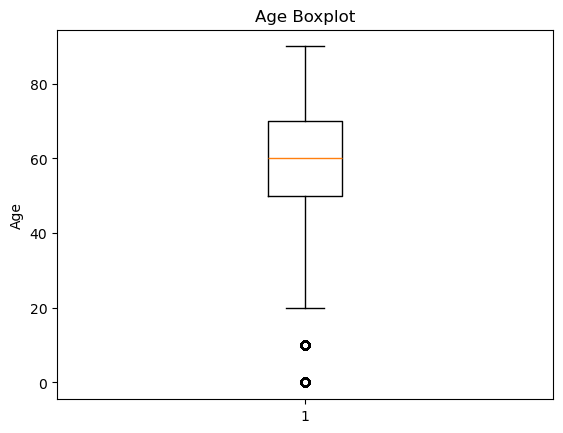

In [15]:
# Check age for outliers. Intuition drives me to remove anyone <20
Q1 = dbts['age'].quantile(0.25)
Q3 = dbts['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dbts[
    (dbts['age'] < lower_bound) |
    (dbts['age'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

print(outliers[['age']].head())

import matplotlib.pyplot as plt

plt.boxplot(dbts['age'])

plt.title('Age Boxplot')
plt.ylabel('Age')

plt.show()

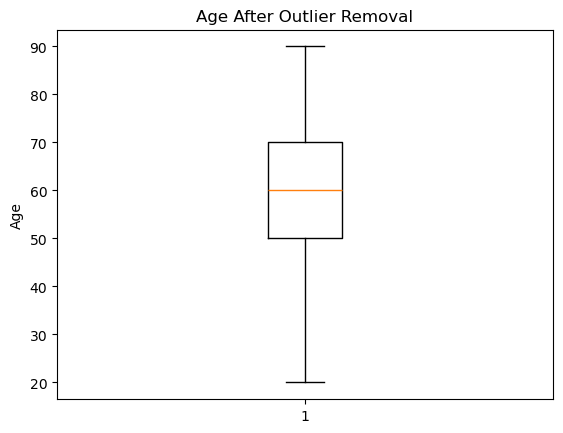

In [16]:
# Removing age outliers (<20)
Q1 = dbts['age'].quantile(0.25)
Q3 = dbts['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only non-outliers
dbts = dbts[
    (dbts['age'] >= lower_bound) &
    (dbts['age'] <= upper_bound)
]

import matplotlib.pyplot as plt

plt.boxplot(dbts['age'])

plt.title('Age After Outlier Removal')
plt.ylabel('Age')

plt.show()

### Splitting the Data: First Encounter
Now that diagnostic codes have been reclassified with their respective broad diagnosis description, age has been corrected and stripped of outliers, and admission type/source, and discharge disposition has been assigned the interpretable string values, we can split the data. 

We will be splitting the data into first encounter, and all others. The first encoutner subset will be our primary dataset for later modeling. 

In [17]:
# Get index of first encounter for each patient
first_idx = dbts.groupby('patient_nbr')['encounter_id'].idxmin()

# Subset 1: first encounter only
first_en= dbts.loc[first_idx]

# Subset 2: all subsequent encounters
subsequent_en= dbts.drop(first_idx)

# Check 
print(first_en['patient_nbr'].value_counts().head())

print(subsequent_en['patient_nbr'].value_counts().head())

patient_nbr
189502619    1
135          1
378          1
729          1
774          1
Name: count, dtype: int64
patient_nbr
88785891    39
88227540    22
23199021    22
43140906    21
84428613    21
Name: count, dtype: int64


### Clustering Model Development
Now that the data has been split into two subsets, we are ready to move forward with developing a clustering model to see if we can risk stratefy the patients. 

In [18]:
first_en.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60590 entries, 4267 to 96147
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              60590 non-null  int64 
 1   patient_nbr               60590 non-null  int64 
 2   race                      60590 non-null  object
 3   gender                    60590 non-null  object
 4   age                       60590 non-null  int64 
 5   admission_type_id         60590 non-null  int64 
 6   discharge_disposition_id  60590 non-null  int64 
 7   admission_source_id       60590 non-null  int64 
 8   time_in_hospital          60590 non-null  int64 
 9   num_lab_procedures        60590 non-null  int64 
 10  num_procedures            60590 non-null  int64 
 11  num_medications           60590 non-null  int64 
 12  number_outpatient         60590 non-null  int64 
 13  number_emergency          60590 non-null  int64 
 14  number_inpatient        

In [19]:
# Removing identifying features to ensure clustering is only based on patient data that can present upon admission
X = first_en.drop(columns=['patient_nbr','encounter_id'])
X = pd.get_dummies(X, drop_first=True)

# Scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce Dimmensionality 
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit(X_scaled)

In [20]:
# Calculate feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)

# Rank feature loadings
important_features = (
    loadings[['PC1', 'PC2', 'PC3']]
    .abs()
    .mean(axis=1)
    .sort_values(ascending=False)
)

print(important_features.head(20))

# Name top features
top_features = important_features.head(10).index.tolist()

print(top_features)

# Reduce dataset to only top features
cluster_X = X[top_features]

dis_dispo_new_Home                  0.229036
change_No                           0.196311
diabetesMed_Yes                     0.191036
ad_type_new_Emergency               0.187350
admission_source_id                 0.186985
metformin_No                        0.183843
admission_type_id                   0.183047
ad_source_new_Physician Referral    0.177707
num_medications                     0.175666
metformin_Steady                    0.174709
time_in_hospital                    0.174666
discharge_disposition_id            0.174455
number_diagnoses                    0.147793
num_lab_procedures                  0.139659
insulin_No                          0.126966
age                                 0.118466
dis_dispo_new_SNF                   0.117296
dis_dispo_new_Other                 0.109153
num_procedures                      0.108210
dis_dispo_new_Home Health           0.108136
dtype: float64
['dis_dispo_new_Home', 'change_No', 'diabetesMed_Yes', 'ad_type_new_Emergency', 'admi

Text(0.5, 1.0, 'Elbow Method')

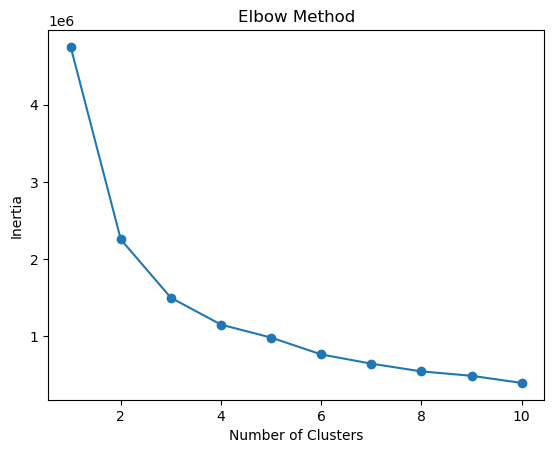

In [21]:
# KMeans Model
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_clusters = kmeans.fit_predict(cluster_X)


# Finding Optimal K 'elbow'
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    model.fit(cluster_X)
    
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# plt.show()

In [22]:
# DBSCAN 

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

dbscan_clusters=dbscan.fit_predict(cluster_X)

In [23]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_clusters=gmm.fit_predict(cluster_X)

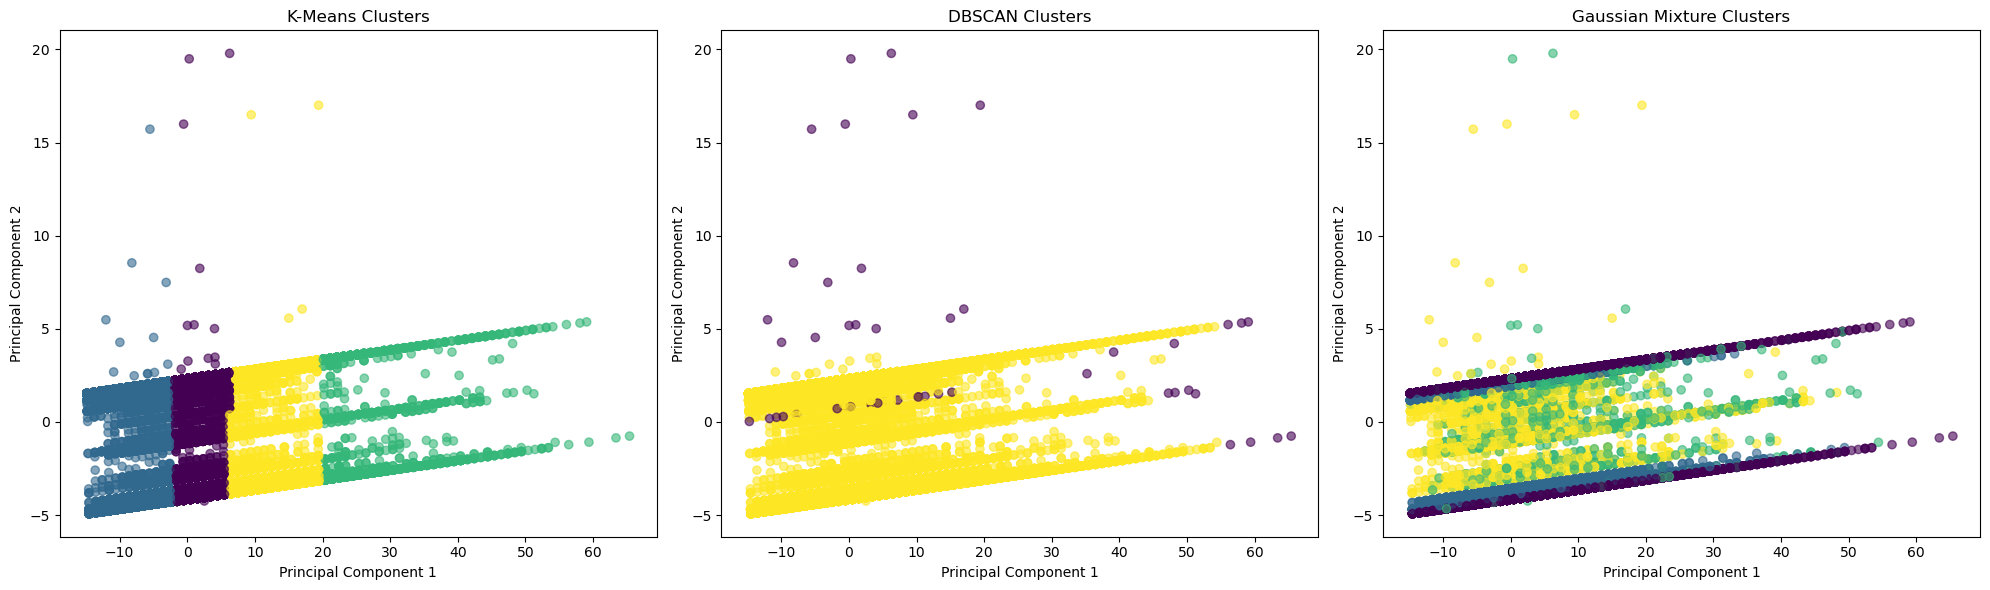

In [24]:
# Plot Clusters Side-by-Side

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

pca_vis = PCA(n_components=2)
X_pca = pca_vis.fit_transform(cluster_X)

#  KMeans
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_clusters,
    alpha=0.6
)

axes[0].set_title('K-Means Clusters')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# DBSCAN
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_clusters,
    alpha=0.6
)

axes[1].set_title('DBSCAN Clusters')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# Gaussian Mixture
axes[2].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_clusters,
    alpha=0.6
)

axes[2].set_title('Gaussian Mixture Clusters')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')

plt.tight_layout()

plt.show()


In [25]:
from sklearn.metrics import silhouette_score

# KMeans
kmeans_sil = silhouette_score(
    cluster_X,
    kmeans_clusters
)

# Gaussian Mixture
gmm_sil = silhouette_score(
    cluster_X,
    gmm_clusters
)

print("KMeans Silhouette Score:", kmeans_sil)
print("GMM Silhouette Score:", gmm_sil)

KMeans Silhouette Score: 0.3711073230436087
GMM Silhouette Score: -0.04481684694886002


In [26]:
# Poor Silhouette score. Ideal would have been >1, but given the low decimals, this indicates a great deal of 
# overlapping clusters. The GMM was significantly worse than the KMeans. Given the poor clustering outcome, it is probable that 
# clustering these patients only with the available data upon presentation is not enough.

### Classification
In this section, we will develop the base classification model for predicting if a patient will be readmitted within 30days of being discharged.


In [27]:
# Defining Target Variable 
pd.set_option('future.no_silent_downcasting', True)
y = first_en['readmitted'].copy()

y = y.replace({
    '<30': 1,
    '>30': 0,
    'NO': 0
})



In [29]:
# Removing target variable from 'X'
X=X.drop(columns=['readmitted_>30','readmitted_NO'])


In [30]:
# Split Test/Train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train=y_train.astype(int)
y_test=y_test.astype(int)

In [31]:
# Scale Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Baseline Model: Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [33]:
# Performance Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     11050
           1       0.57      0.00      0.01      1068

    accuracy                           0.91     12118
   macro avg       0.74      0.50      0.48     12118
weighted avg       0.88      0.91      0.87     12118

AUC: 0.6420208619316352
[[11047     3]
 [ 1064     4]]


In [ ]:
# Confusion matrix shows and AUC score of 64%. We can see the model predicts "0" well, but not "1".

### Criteria
Organization: readme w/ findings & link to jupyter notebooke, notebook w/ headings an text

Syntax & Code: libraries are improted and aliased, code doesn't contain errors, no long strings of code output, demonstrate competency w/ pandas, visuzalization libraries, comments used, variables sensible

VISUALIZATIONS: appropriate plots for categorical and continuous variables, readable labels, contain descrptive titles, axes are legible, subplots when appropriate, scaled 

Data Cleaning and EDA: dataset is clean, imputaiton and removal of missing values, removal of duplicate values, outliers analysis to identify anomolies in dataset, perform feature engineering to extraction and transformatino of variables from raw data

Modeling: develop an apprpriate classificaiton or regression ML model to utilize as baseline for anlaysis, valid interpretation of an evaluation metric, clear idnetification of evaluation metric, clear rationale for use of given evaluation metric


##### Questions